In [ ]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — Mean Squared Error:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели, его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов

Для того чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его не нужно. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения градиента (вектор)

In [ ]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактоного класса: Mean Squared Error лосс.

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`

Он должен вычислять лосс и градиент по формулам наверху

In [ ]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        l = X.shape[0]
        Q = (1 / l) * np.linalg.norm(np.dot(X, w)  - y) ** 2
        return Q

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        l = X.shape[0]
        gr = (2 / l) * np.dot(X.T, (np.dot(X, w) - y))
        return gr

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [ ]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")
print(X.shape, w.shape)
X.dot(w)


27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!
(20, 10) (10,)


array([ 285,  735, 1185, 1635, 2085, 2535, 2985, 3435, 3885, 4335, 4785,
       5235, 5685, 6135, 6585, 7035, 7485, 7935, 8385, 8835])

Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^t = w^{t-1} - \eta \nabla_{w} Q(w^{t-1}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`,
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше и возвращать
траекторию спуска (список из новых значений весов на каждом шаге)

In [ ]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    weights = np.zeros((n_iterations + 1, w_init.shape[0]))
    weights[0] = w_init
    for i in range(1, n_iterations + 1):
        w = w_init - lr * loss.calc_grad(X, y, w_init)
        weights[i] = w
        w_init = w
    return weights

Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории:

In [ ]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :]
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [ ]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

425.5891768045025
0.8670644395649495


In [ ]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("equal")

    # visualize the level set
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # visualize trajectory
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте не менее четырёх разных значений для `lr`.

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1

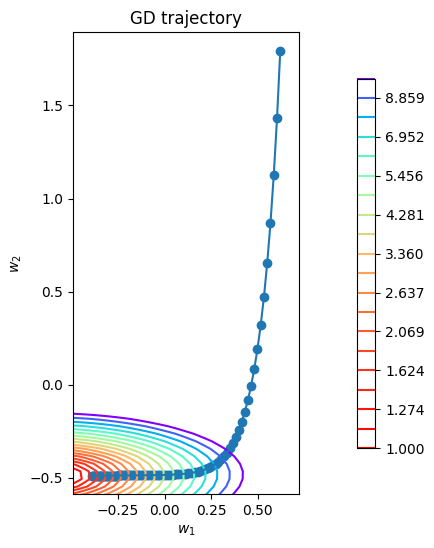

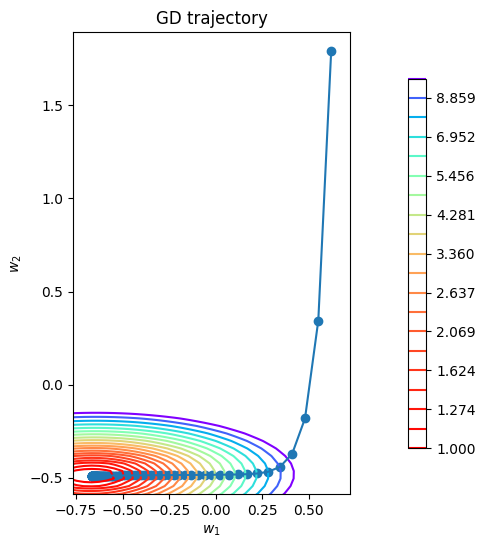

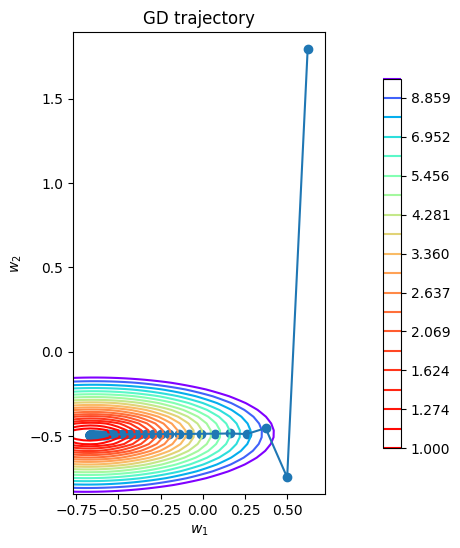

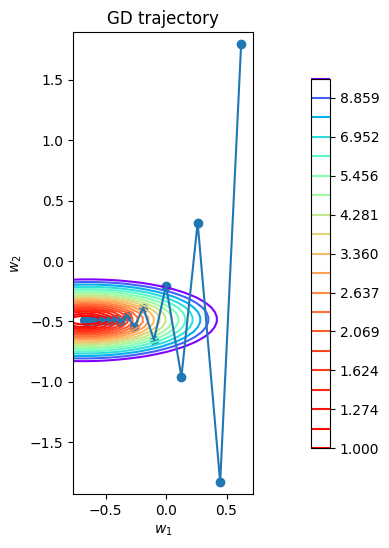

In [ ]:
lr_list = np.linspace(0.001, 0.01, 4)

for lr in lr_list:
    plot_gd(gradient_descent(w_init, X, y, loss, lr, 100), X, y, loss)

### Вывод: при увеличении параметра длины шага градиентный спуск начинает сильнее колбасить, так как при большом шаге, хоть и веса двигаются в направлении минимума, их может отбросить слишком сильно.

Теперь реализуем стохастический градиентный спуск

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [ ]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    batch_indices = np.random.choice(X.shape[0], size = batch_size, replace = False)
    batch = X[batch_indices]
    weights_batch = np.zeros((n_iterations + 1, w_init.shape[0]))
    weights_batch[0] = w_init
    for i in range(1, n_iterations + 1):
        w = w_init - lr * loss.calc_grad(batch, y[batch_indices], w_init)
        weights_batch[i] = w
        w_init = w
    return weights_batch

**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

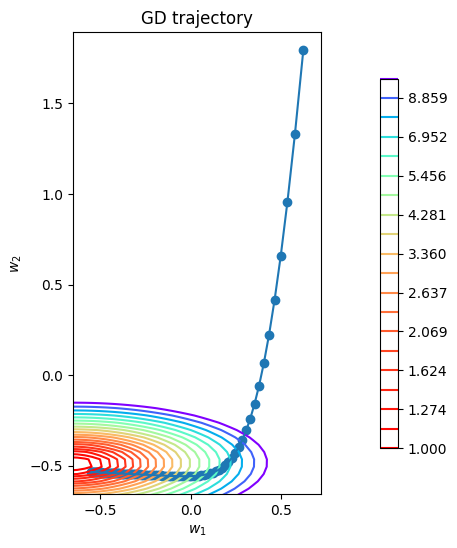

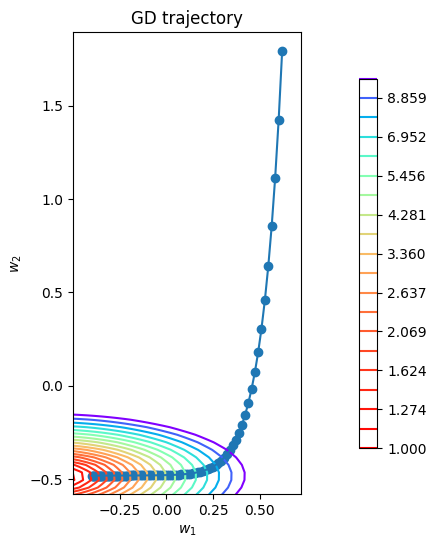

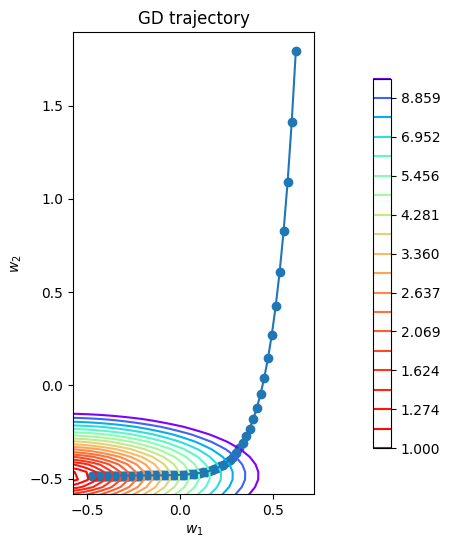

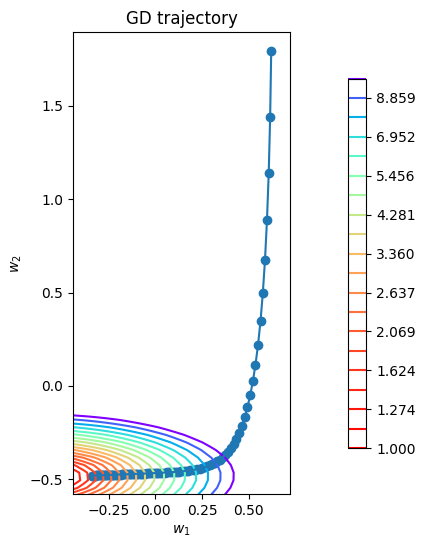

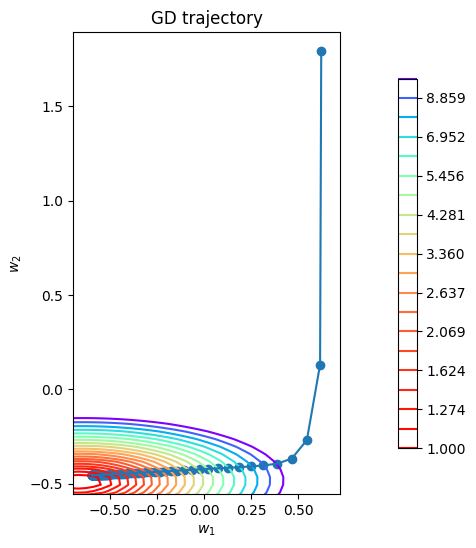

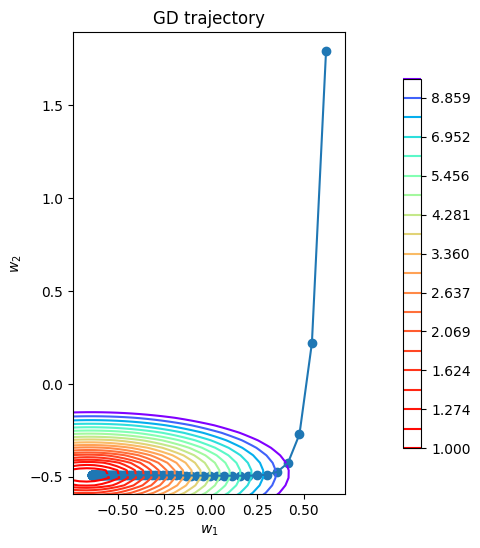

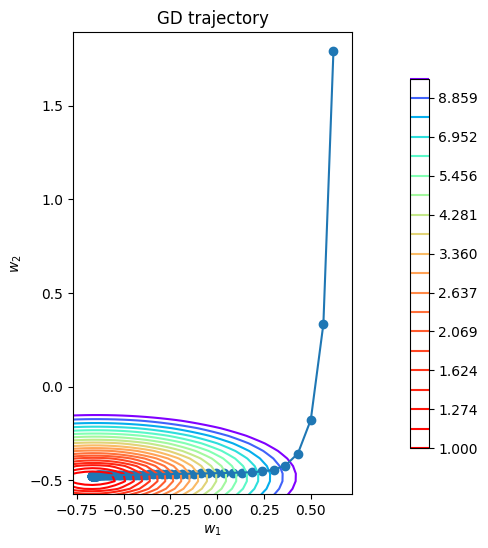

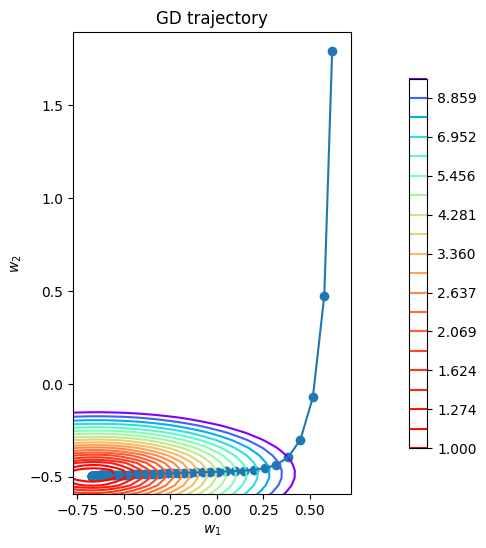

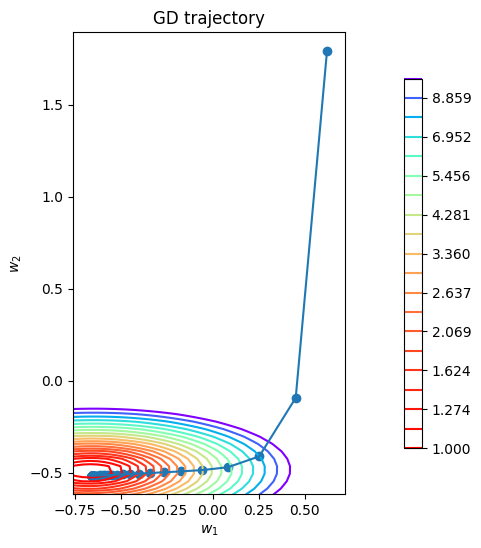

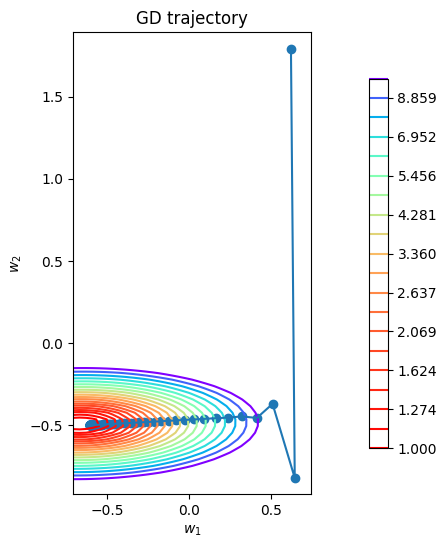

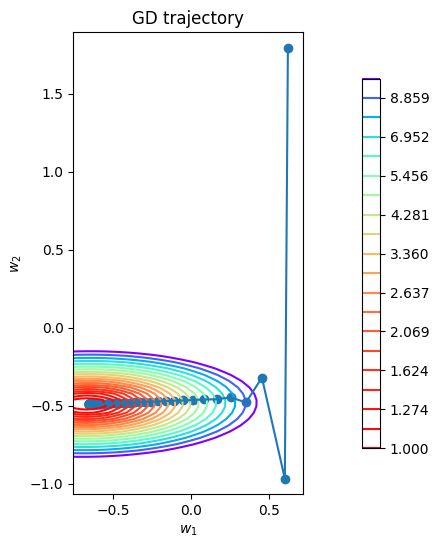

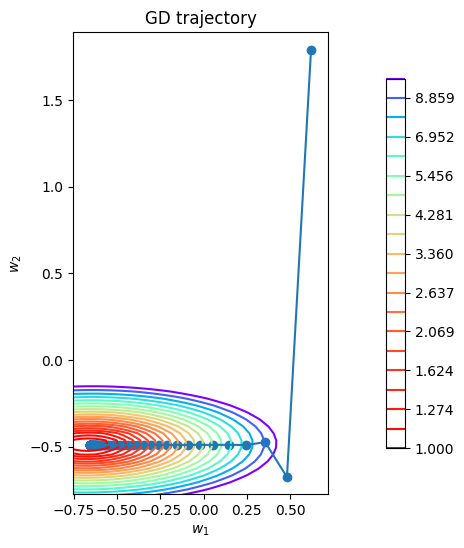

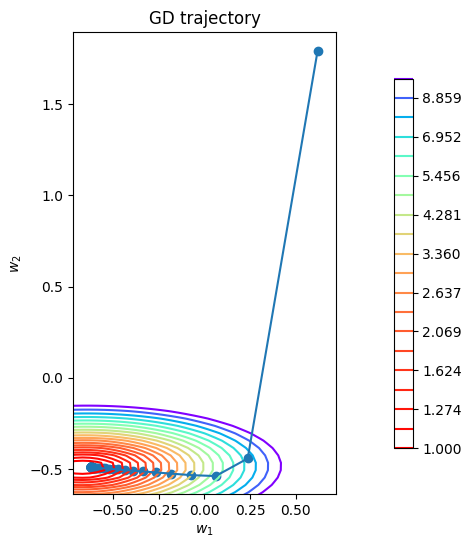

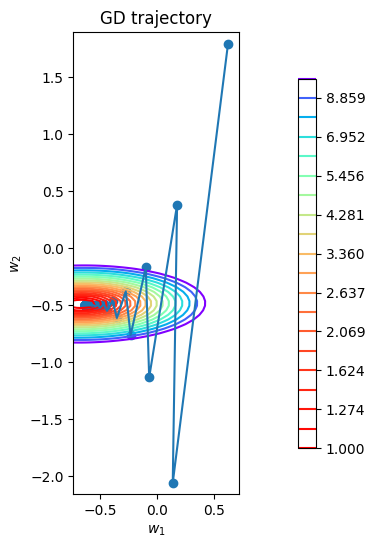

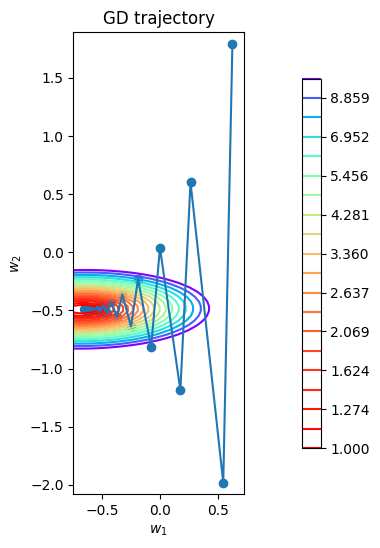

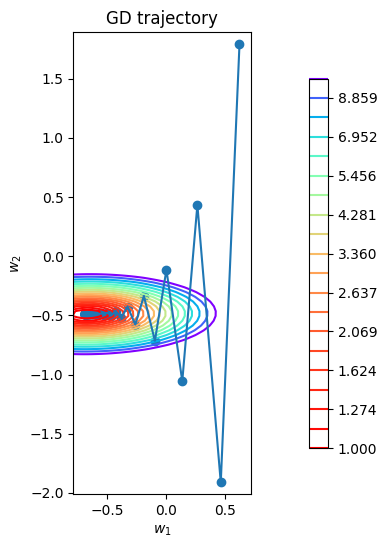

In [ ]:
np.random.seed(10)
batch_list = [10, 50, 100, 200]
for lr in lr_list:
    for batch in batch_list:
        plot_gd(stochastic_gradient_descent(w_init, X, y, loss, lr, batch, 100), X, y, loss)

### Вывод:

По отдельности увеличение batch size приводит к более плавному градиентному спуску (так как ближе к размеру всей выборки), значение длины шага обратно пропорционально плавности спуска.

Смотря на графики, можно заметить, что при низких значениях длины шага
с увеличением batch size градиентный спуск становится более плавным, но при высоких значениях lr чем выше batch size, тем сильнее трясет градиентный спуск.

С высоким batch size градиентный спуск ведет себя почти как вся выборка, поэтому при высоких lr его также колбасит.

Стохастический градиентный спуск ведет себя менее стабильно, чем обычный градиентный спуск, так как используетс лишь часть выборки, она в целом отвечает за направление к минимуму, но иногда полная выборка может хотеть идти немного в другое направление, чем часть.

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы более точнее этого минимума достичь и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [ ]:
def stochastic_gradient_descent2(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float -- значение степени в формуле затухания длины шага
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    batch_indices = np.random.choice(X.shape[0], size = batch_size, replace = False)
    batch = X[batch_indices]
    weights_batch = np.zeros((n_iterations + 1, w_init.shape[0]))
    weights_batch[0] = w_init
    for i in range(1, n_iterations + 1):
        w = w_init - (lr * (1 / i) ** p) * loss.calc_grad(batch, y[batch_indices], w_init)
        weights_batch[i] = w
        w_init = w
    return weights_batch

**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска

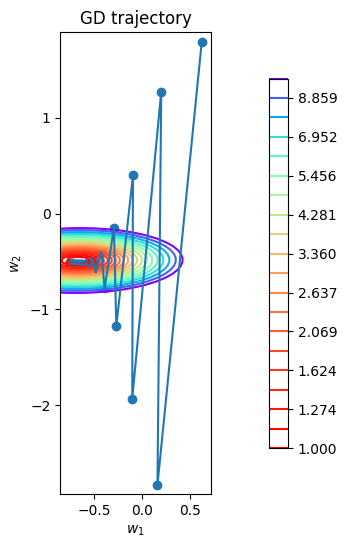

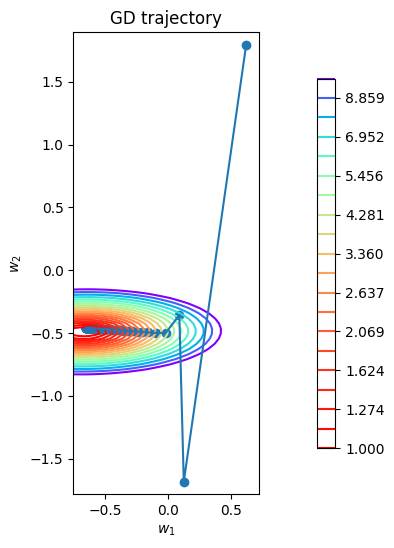

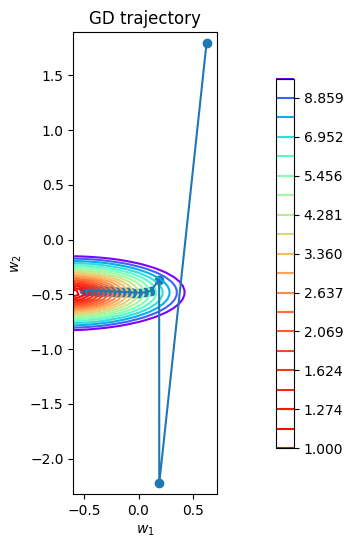

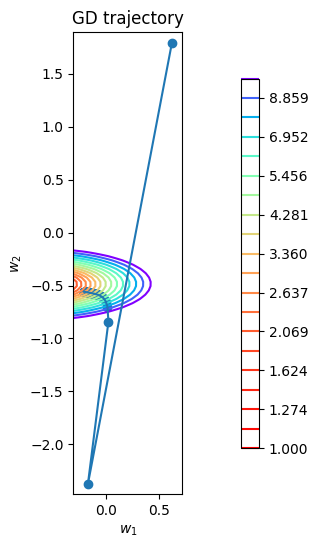

In [ ]:
np.random.seed(10)
p_list = np.linspace(0.1, 1, 4)
for p in p_list:
    plot_gd(stochastic_gradient_descent2(w_init, X, y, loss, 0.01, 10, p, 100), X, y, loss)

### Вывод:

С увеличением параметра p снижается значение шага с каждым следующим шагом, поэтому с меньшими p все шаги довольно большие, и спуск нестабильный; при больших p первые несколько шагов большие, но они намного быстрее снижаются, из-за чего спуск становится более плавным, но так он может не дойти до минимума по причине очень маленького значения шага (кажется, так и произошло на последнем графике)

**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

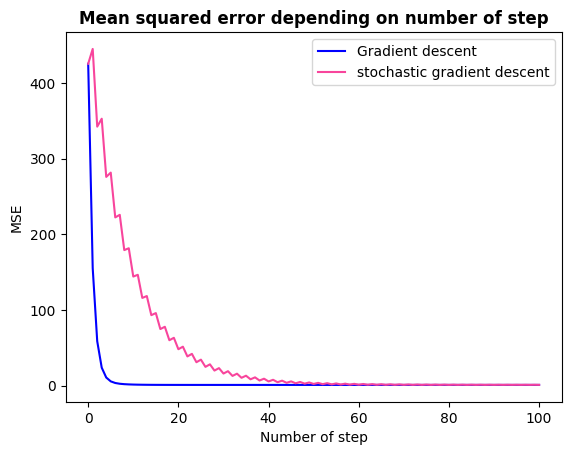

In [ ]:
np.random.seed(10)
from matplotlib import gridspec

loss1 = MSELoss()
loss_gd = np.array([])
loss_sgd = np.array([])
w_list_gd = gradient_descent(w_init, X, y, loss1, 0.01, 100)
w_list_sgd = stochastic_gradient_descent(w_init, X, y, loss1, 0.01, 10, 100)

for i in range(w_list_gd.shape[0]):
    loss_gd = np.append(loss_gd, loss1.calc_loss(X, y, w_list_gd[i]))
    loss_sgd = np.append(loss_sgd, loss1.calc_loss(X, y, w_list_sgd[i]))

plt.plot(np.arange(w_list_gd.shape[0]), loss_gd, color = 'blue', label = 'Gradient descent')
plt.plot(np.arange(w_list_sgd.shape[0]), loss_sgd, color = '#f8459c', label = 'stochastic gradient descent')
plt.title('Mean squared error depending on number of step', weight = 'heavy')
plt.xlabel('Number of step')
plt.ylabel('MSE')
plt.legend()
plt.show()

### Вывод:

На данном графике не наблюдается преимущество SGD, так как он сходится медленнее, чем обычный GD, при этом сходится не плавно (MSE то растет, то падает). Однако, если к этому привяать факт, что в SGD используется намного меньше наблюдений (всего 10 против 300 в изначальном массиве). Поэтому, возможно, SGD быстрее справится с поиском минимума (при GD придется считать градиенты в 30 раз больше, а при SGD сделать в ~15 раз больше шагов)

## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`

В методе `predict` мы будем применять нашу регрессию к датасету,

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

In [ ]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        w_init = np.random.uniform(-2, 2, (X.shape[1]))

        w_list = gradient_descent(w_init, X, y, self.loss, self.lr)
        self.w = w_list[-1]
        return self.w

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        y_pred = X.dot(self.w)
        return y_pred

Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [ ]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [ ]:
import pandas as pd

X_raw = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data",
    header=None,
    na_values=["?"],
)

X_raw = X_raw[~X_raw[25].isna()].reset_index()
X_raw.head()

,index,0,1,2,3,4,5,6,7,8,...,16,17,18,19,20,21,22,23,24,25
0,0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,3,2,164.0,audi,gas,std,four,sedan,fwd,front,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,4,2,164.0,audi,gas,std,four,sedan,4wd,front,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [ ]:
y = X_raw[25]
X_raw = X_raw.drop(25, axis=1)
# дроп столбец index, так как он не несет никакой смысловой нагрузки
X_raw = X_raw.drop(columns = 'index')

**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

In [ ]:
# закодируем категориальные признаки
cat = (X_raw.dtypes == 'object').values
X_cat = pd.get_dummies(X_raw[X_raw.columns[cat]]) * 1
X_raw2 = pd.concat((X_raw.drop(columns = X_raw.columns[cat]), X_cat), axis = 1)
X_raw2.head()

,0,1,9,10,11,12,13,16,18,19,...,15_twelve,15_two,17_1bbl,17_2bbl,17_4bbl,17_idi,17_mfi,17_mpfi,17_spdi,17_spfi
0,3,NaN,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0,0,0,0,0,0,0,1,0,0
1,3,NaN,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0,0,0,0,0,0,0,1,0,0
2,1,NaN,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,0,0,0,0,0,0,0,1,0,0
3,2,164.0,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,0,0,0,0,0,0,0,1,0,0
4,2,164.0,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
# разделим датасет на обучающую и тестовую выборку
np.random.seed(666)
from sklearn.model_selection import train_test_split
bins1 = np.linspace(np.min(y), np.max(y) + 1, 10)
y_binned = np.digitize(y, bins = bins1)
X_train, X_test, y_train, y_test = train_test_split(X_raw2, y, test_size = 0.3, stratify = y_binned)

In [ ]:
# количество пропущенных значений
pd.DataFrame({'X_train': X_train.isna().sum().values, 'X_test': X_train.isna().sum().values, 'y_train': y_train.isna().sum(), 'y_test': y_test.isna().sum()}).head(10)

,X_train,X_test,y_train,y_test
0,0,0,0,0
1,26,26,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0
5,0,0,0,0
6,0,0,0,0
7,0,0,0,0
8,3,3,0,0
9,3,3,0,0


In [ ]:
# заполним пропуски числовых признаков средними по выборке train
# в категориальных признаках все nan проигнорировались после one hot encoding, поэтому там нет пустых значений
from sklearn.impute import SimpleImputer

X_train_cat = X_train.drop(columns = X_raw.columns[~ cat]).reset_index(drop = True)
X_test_cat = X_test.drop(columns = X_raw.columns[~ cat]).reset_index(drop = True)
X_train_real = X_train[X_raw.columns[~ cat]].reset_index(drop = True)
X_test_real = X_test[X_raw.columns[~ cat]].reset_index(drop = True)

replacer = SimpleImputer(strategy = 'mean')
replacer.fit(X_train_real)
X_train_real2 = pd.DataFrame(data = replacer.transform(X_train_real), columns = X_train_real.columns)
X_test_real2 = pd.DataFrame(data = replacer.transform(X_test_real), columns = X_train_real.columns)

In [ ]:
# нормализуем числовые признаки
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train_real2)
X_norm_train = pd.DataFrame(scaler.transform(X_train_real2), columns = X_train_real2.columns)
X_norm_test = pd.DataFrame(scaler.transform(X_test_real2), columns = X_train_real2.columns)

In [ ]:
# соединим все вместе
X_train2 = pd.concat([X_norm_train, X_train_cat], axis = 1)
X_test2 = pd.concat([X_norm_test, X_test_cat], axis = 1)

**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [ ]:
np.random.seed(666)
linear_regression.fit(X_train2, y_train)
linear_regression.predict(X_train2)

array([15106.11962131,  7931.80054465, 14215.23201609, 17264.67465784,
       35179.07933611,  8876.11445622,  6780.39394738,  6646.09603059,
       14719.70956512, 12161.40209467, 12440.95608   , 15962.62280665,
        9778.69734394, 42719.96533886,  8115.16033485, 10027.51549157,
        7758.19557776, 13781.39273361, 27678.65668537, 19649.8528425 ,
        6606.41406697,  5860.23317581,  9072.8724443 , 13577.05998993,
       14935.94828747, 16502.91577688,  7139.09334256,  5917.39334079,
       14647.14108289,  9130.53111916, 11243.10404981,  8421.73225052,
        8138.47184645, 16034.9214912 , 18862.1674859 ,  9970.49320747,
        6396.33607367, 18666.01885279,  6497.55040729,  9411.31960566,
        6153.18680276, 11688.81302086, 11744.44391748, 14940.45294673,
        6787.80850482, 11475.35081062,  9167.96415957, 15795.67867833,
        6295.07522012, 22017.91411864, 10344.91793951, 12128.98941638,
       11444.08952699, 16034.9214912 ,  8865.56873902, 16947.12580795,
      

**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [ ]:
from sklearn.metrics import mean_squared_error
np.random.seed(666)
linear_regression.fit(X_train2, y_train)
print(f'MSE on train =', mean_squared_error(y_train, linear_regression.predict(X_train2)))
print(f'MSE on test =', mean_squared_error(y_test, linear_regression.predict(X_test2)))

MSE on train = 1323209.1096512896
MSE on test = 6754725.664812106


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`

Он должен вычислять лосс и градиент по формулам наверху

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`

In [ ]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        l = X.shape[0]
        Q = (1 / l) * np.linalg.norm(np.dot(X, w)  - y) ** 2 + self.coef * np.linalg.norm(w[:-1]) ** 2
        return Q

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        l = X.shape[0]
        w[-1] = 0
        gr = (2 / l) * np.dot(X.T, (np.dot(X, w) - y)) + 2 * self.coef * w
        return gr

Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [ ]:
linear_regression_l2 = LinearRegression(MSEL2Loss(0.1))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

In [ ]:
np.random.seed(666)
linear_regression_l2.fit(X_train2, y_train)
print(f'MSE on train =', mean_squared_error(y_train, linear_regression_l2.predict(X_train2)))
print(f'MSE on test =', mean_squared_error(y_test, linear_regression_l2.predict(X_test2)))
# здесь ошибка сильно увеличилась

MSE on train = 5711718.130817151
MSE on test = 14385652.553981785


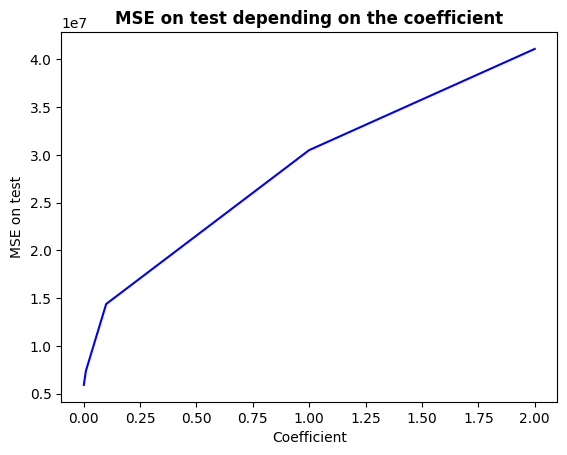

Видно, что с ростом коэффициента увеличивется ошибка, оптимальный близко к 0


In [ ]:
# посмотрим, как ведет себя ошибка при разных coef
np.random.seed(666)
MSE_test = np.array([])
for i in np.array([0.001, 0.01, 0.1, 1, 2]):
    lr_l2 = LinearRegression(MSEL2Loss(i))
    lr_l2.fit(X_train2, y_train)
    MSE_test = np.append(MSE_test, mean_squared_error(y_test, lr_l2.predict(X_test2)))
plt.plot(np.array([0.001, 0.01, 0.1, 1, 2]), MSE_test, color = 'blue')
plt.title('MSE on test depending on the coefficient', fontweight = 'heavy')
plt.xlabel('Coefficient')
plt.ylabel('MSE on test')
plt.show()
print('Видно, что с ростом коэффициента увеличивется ошибка, оптимальный близко к 0')

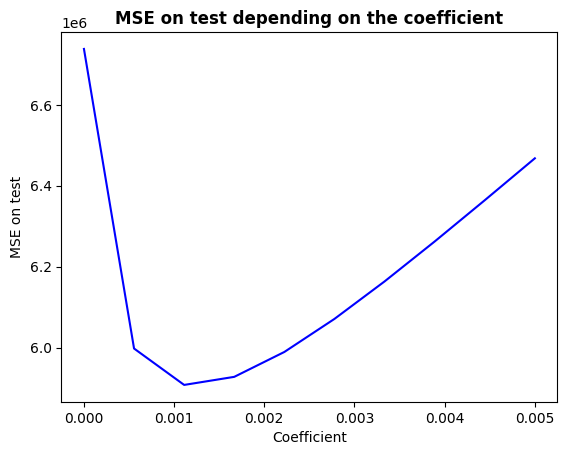


 Наименьшая ошибка 5907542.030283523 при коэффициенте регуляризации = 0.0011111111111111111


In [ ]:
np.random.seed(666)
coefs = np.linspace(0, 0.005, 10)
MSE_test2 = np.array([])
for i in coefs:
    lr_l2 = LinearRegression(MSEL2Loss(i))
    lr_l2.fit(X_train2, y_train)
    MSE_test2 = np.append(MSE_test2, mean_squared_error(y_test, lr_l2.predict(X_test2)))
plt.plot(coefs, MSE_test2, color = 'blue')
plt.title('MSE on test depending on the coefficient', fontweight = 'heavy')
plt.xlabel('Coefficient')
plt.ylabel('MSE on test')
plt.show()
print('\n', f'Наименьшая ошибка {np.min(MSE_test2)} при коэффициенте регуляризации = {coefs[np.argmin(MSE_test2)]}')

In [ ]:
# коэфициент = 0.001
np.random.seed(666)
linreg_l2 = LinearRegression(MSEL2Loss(0.001))
linear_regression.fit(X_train2, y_train)
linreg_l2.fit(X_train2, y_train)

MSE_lr_train = mean_squared_error(y_train, linear_regression.predict(X_train2))
MSE_l2_train = mean_squared_error(y_train, linreg_l2.predict(X_train2))

MSE_lr_test = mean_squared_error(y_test, linear_regression.predict(X_test2))
MSE_l2_test = mean_squared_error(y_test, linreg_l2.predict(X_test2))

print(f'MSE на train увеличилась с {round(MSE_lr_train, 3)} до {round(MSE_l2_train, 3)} на {round((MSE_l2_train - MSE_lr_train) / MSE_lr_train * 100, 3)} %')
print(f'MSE на test снизилась с {round(MSE_lr_test, 3)} до {round(MSE_l2_test, 3)} на {abs(round((MSE_l2_test - MSE_lr_test) / MSE_lr_test * 100, 3))} %')
print('Модель в какой то степени справляется с переобучением, так как ошибка на тесте снизилась')

MSE на train увеличилась с 1323209.11 до 1431735.592 на 8.202 %
MSE на test снизилась с 6754725.665 до 5912650.692 на 12.466 %
Модель в какой то степени справляется с переобучением, так как ошибка на тесте снизилась


В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`

Он должен вычислять лосс и градиент по формулам наверху

In [ ]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        l = X.shape[0]
        z = np.dot(X, w) - y
        mask1 = (z < self.eps) & (z > -self.eps)
        mask2 = (z >= self.eps) | (z <= -self.eps)
        z1 = z[mask1] ** 2 * (1 / 2)
        z2 = self.eps * (abs(z[mask2]) - (1 / 2) * self.eps)
        Q = np.sum(np.append(z1, z2)) / l
        return Q

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        l = X.shape[0]
        z = np.dot(X, w) - y
        mask1 = (z < self.eps) & (z > -self.eps)
        fi = mask1 * z + self.eps * np.sign(~mask1 * z)
        grad = np.sum(X.T * fi, axis = 1) / l
        return grad

**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [ ]:
np.random.seed(666)
MSE_hl = np.array([])
epss = np.linspace(10, 3000, 5)
for i in epss:
    linreg_hl = LinearRegression(HuberLoss(i))
    linreg_hl.fit(X_train2, y_train)
    MSE_hl = np.append(MSE_hl, mean_squared_error(y_test, linreg_hl.predict(X_test2)))
print(MSE_hl)
print('Нужно брать более высокий коэффициент')

[13840157.69194104  7157226.5515304   6623959.07725382  6842680.61871491
  6765670.69487545]
Нужно брать более высокий коэффициент


In [ ]:
np.random.seed(666)
MSE_hl2 = np.array([])
epss2 = np.linspace(1000, 10000, 10)
for i in epss2:
    linreg_hl = LinearRegression(HuberLoss(i))
    linreg_hl.fit(X_train2, y_train)
    MSE_hl2 = np.append(MSE_hl2, mean_squared_error(y_test, linreg_hl.predict(X_test2)))
print(MSE_hl2)
print('Не очень понятно, в каком промежутке находится оптимальный коэффициент, так как он скачет((')

[6893618.38416046 6783367.50176619 6765343.23482587 6724504.49698213
 6725254.74257622 6725134.08390011 6724564.42958184 6724855.10342836
 6725148.30039649 6724642.16972312]
Не очень понятно, в каком промежутке находится оптимальный коэффициент, так как он скачет((


In [ ]:
np.random.seed(666)
MSE_hl3 = np.array([])
epss3 = np.linspace(5000, 100000, 100)
for i in epss3:
    linreg_hl = LinearRegression(HuberLoss(i))
    linreg_hl.fit(X_train2, y_train)
    MSE_hl3 = np.append(MSE_hl3, mean_squared_error(y_test, linreg_hl.predict(X_test2)))
print(MSE_hl3)

[6725246.17231539 6724874.31008422 6724945.65459665 6724555.81568799
 6725272.14833305 6725139.29766056 6724566.02071988 6724855.9094049
 6725148.86437075 6724642.6148478  6724760.15250318 6725228.25454051
 6724931.38224807 6724901.98237691 6725183.09912552 6725467.85125629
 6724876.00564368 6724845.16389879 6724983.48701455 6724874.51237251
 6725212.77551674 6724577.34348087 6724886.71729257 6724789.79042407
 6724519.1314832  6725132.18757643 6725247.53814271 6724624.26998101
 6724818.57015585 6724674.06215473 6724469.067208   6725453.13459325
 6725187.89446491 6725249.650433   6725130.13198876 6724578.86337483
 6724955.62332425 6724955.53340198 6724913.09758308 6724859.58198073
 6725270.83217432 6724936.72303608 6725381.52521267 6725525.45293227
 6725164.65712019 6725098.5122546  6725423.6051253  6724766.46237934
 6725026.59699751 6725394.00555723 6725394.20359809 6724805.5929243
 6724732.15416765 6725493.63833203 6725020.43103515 6725264.71234461
 6724799.86279683 6725235.95472064 6

При переборе различных значений гиперпараметра MSE оставалась примерно на одном уровне

In [ ]:
linreg_hl3 = LinearRegression(HuberLoss(5000))
linreg_hl3.fit(X_train2, y_train)
print(f'MSE on Train: {mean_squared_error(y_train, linreg_hl3.predict(X_train2))}')
print(f'MSE on Test: {mean_squared_error(y_test, linreg_hl3.predict(X_test2))}')
print('По сравнению с регрессией, обученной с MSELoss, с регрессией с HuberLoss MSE на тесте снизилась, что говорит о том, что модель справляется с проблемой выбросов')

MSE on Train: 1323277.1978024729
MSE on Test: 6725532.218369306
По сравнению с регрессией, обученной с MSELoss, с регрессией с HuberLoss MSE на тесте снизилась, что говорит о том, что модель справляется с проблемой выбросов


**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2021 в ячейку ниже:

<center>
<img src="https://n1s1.hsmedia.ru/7d/5b/ee/7d5bee1bcba4f18d587e91958a28f719/676x600_0xac120003_19882481081639574638.jpeg" height="500">
</center>